In [5]:
import carbonfluxbench
import os
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error

In [6]:
def q25(x):
    return x.quantile(0.25)

def q75(x):
    return x.quantile(0.75)

In [4]:
micasa = pd.read_parquet('../data/MiCASA.parquet')
micasa = micasa.rename(columns={'TIMESTAMP': 'date'})
micasa['site'] = [x.split('_')[1] for x in micasa.site.values]
micasa = micasa.loc[micasa[['date', 'site']].drop_duplicates().index]
micasa

,date,site,NPP,Rh,NEE
0,2001-01-01,AR-CCg,3.363847,2.077697,-1.449279
1,2001-01-01,AR-TF1,2.690750,1.384982,-1.348545
2,2001-01-01,BR-CST,1.561390,1.094100,-0.474748
3,2001-01-01,BR-Npw,3.988564,3.750629,-0.239169
4,2001-01-01,CA-ARB,0.000000,0.487960,0.487731
...,...,...,...,...,...
5022913,2024-12-31,RU-Sk2,0.000000,0.086602,0.078941
5022914,2024-12-31,RU-SkP,0.000000,0.086602,0.078941
5022915,2024-12-31,RU-Tur,0.000000,0.348249,0.290447
5022916,2024-12-31,TH-Kog,2.038347,3.002300,0.872043


In [12]:
targets = ['GPP_NT_VUT_USTAR50', 'RECO_NT_VUT_USTAR50', 'NEE_VUT_USTAR50']
include_qc = True
test_QC_threshold = 1 
y = carbonfluxbench.load_targets(targets, include_qc)

for split_type in ['Koppen', 'IGBP']:
    y_train, y_test = carbonfluxbench.split_targets(y, split_type, verbose=False, plot=False)
    modis = carbonfluxbench.load_modis()

    era_feature_set = 'minimal' # minimal (6), standard (36), full (150)
    era = carbonfluxbench.load_era(era_feature_set)

    _, _, test, _, _ = carbonfluxbench.join_features(y_train, y_test, modis, era, scale=False)
    x_test, test, _, dates = carbonfluxbench.tabular(test, targets, include_qc, test_QC_threshold, cat_features=['IGBP', 'Koppen', 'Koppen_short'], return_dates=True)
    test['site'] = x_test['site'].values
    test['IGBP'] = x_test['IGBP'].values
    test['Koppen'] = x_test['Koppen'].values
    test['date'] = dates

    merged = pd.merge(test, micasa, on=['site', 'date'], how='left')
    merged = merged[['date', 'site', 'IGBP', 'Koppen', 'GPP_NT_VUT_USTAR50', 'RECO_NT_VUT_USTAR50', 'NEE_VUT_USTAR50', 'NPP', 'Rh', 'NEE']]
    print(f"{split_type} Missing samples: {len(merged[merged.isna().any(axis=1)])} / {len(merged)}")
    merged = merged.dropna()

    flux2micasa = {'GPP_NT_VUT_USTAR50': 'NPP', 'RECO_NT_VUT_USTAR50': 'Rh', 'NEE_VUT_USTAR50': 'NEE'}
    res = {target: {'site': [], 'IGBP': [], 'Koppen': [], 
                            'R2': [], 'RMSE': [], 'nMAE': [],
                             'RAE': [],} for target in targets}
    all_results = []
    for site in merged.site.unique():
        for idx, target in enumerate(targets):
            y_site = merged[merged.site==site][target]
            preds = merged[merged.site==site][flux2micasa[target]]
            res[target]['site'].append(site)
            res[target]['IGBP'].append(merged[merged.site==site].IGBP.values[0])
            res[target]['Koppen'].append(merged[merged.site==site].Koppen.values[0])
            res[target]['R2'].append(r2_score(y_site, preds))
            res[target]['RMSE'].append(root_mean_squared_error(y_site, preds))
            res[target]['RAE'].append(carbonfluxbench.relative_absolute_error(y_site, preds))
            res[target]['nMAE'].append(carbonfluxbench.normalized_mae(np.mean(y_site), y_site, preds))
        df = pd.DataFrame(res[target])
        df['target'] = target
        df['model'] = 'micasa'
        df['split_type'] = split_type
        all_results.append(df)
    all_results = pd.concat(all_results, axis=0)
    #all_results.to_csv(f'./eval_results/micas_{split_type}.csv', index=None)
    for target in targets:
        res[target] = pd.DataFrame(res[target])
        r = res[target]
        print(f"{target}:\t{r['R2'].median():.3f}\t{r['RMSE'].mean():.3f}\t{r['RAE'].median():.3f}\t{r['nMAE'].median():.3f}")

/users/4/rozan012/CarbonBench/carbonfluxbench/utils/processing.py:284: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[cat_features] = X[cat_features].astype('category')


Koppen Missing samples: 1012 / 86527
GPP_NT_VUT_USTAR50:	0.124	2.958	0.806	0.638
RECO_NT_VUT_USTAR50:	-0.174	2.303	0.960	0.587
NEE_VUT_USTAR50:	0.133	1.733	0.891	2.333


/users/4/rozan012/CarbonBench/carbonfluxbench/utils/processing.py:284: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[cat_features] = X[cat_features].astype('category')


IGBP Missing samples: 1469 / 113679
GPP_NT_VUT_USTAR50:	0.114	2.920	0.797	0.679
RECO_NT_VUT_USTAR50:	-0.228	2.212	0.985	0.592
NEE_VUT_USTAR50:	-0.005	1.750	0.972	2.167


In [10]:
splits = ['IGBP', 'Koppen']
for split in splits:
    print(split)
    dfs = [pd.read_csv(f'./eval_results/{f}') for f in os.listdir('./eval_results') if split in f and 'full' in f]
    df = pd.concat(dfs, axis=0)
    df = df.groupby(['model', 'target'])[['R2', 'RMSE', 'RAE', 'nMAE']].agg({
        'R2': ['median', q25, q75],
        'RMSE': ['median', q25, q75],
        'RAE': ['median', q25, q75],
        'nMAE': ['median', q25, q75]
    }).round(3)
    print(df)

IGBP
                                          R2                 RMSE         \
                                      median    q25    q75 median    q25   
model             target                                                   
ctgru             GPP_NT_VUT_USTAR50   0.538  0.217  0.710  1.802  1.173   
                  NEE_VUT_USTAR50      0.159 -0.368  0.359  1.588  0.982   
                  RECO_NT_VUT_USTAR50  0.438 -0.159  0.687  1.222  0.811   
ctlstm            GPP_NT_VUT_USTAR50   0.561  0.111  0.740  1.676  1.112   
                  NEE_VUT_USTAR50      0.207 -0.134  0.438  1.467  0.844   
                  RECO_NT_VUT_USTAR50  0.443 -0.162  0.661  1.193  0.774   
gru               GPP_NT_VUT_USTAR50   0.420 -0.009  0.692  1.794  1.215   
                  NEE_VUT_USTAR50      0.150 -0.077  0.373  1.444  0.958   
                  RECO_NT_VUT_USTAR50  0.393 -0.513  0.640  1.215  0.788   
lstm              GPP_NT_VUT_USTAR50   0.498 -0.095  0.705  1.889  1.138   
       

In [13]:
splits = ['IGBP', 'Koppen']
for split in splits:
    dfs = [pd.read_csv(f'./eval_results/{f}') for f in os.listdir('./eval_results') if split in f]
    df = pd.concat(dfs, axis=0)

In [14]:
plt.rc('xtick', labelsize=20)
plt.rc('ytick', labelsize=20)

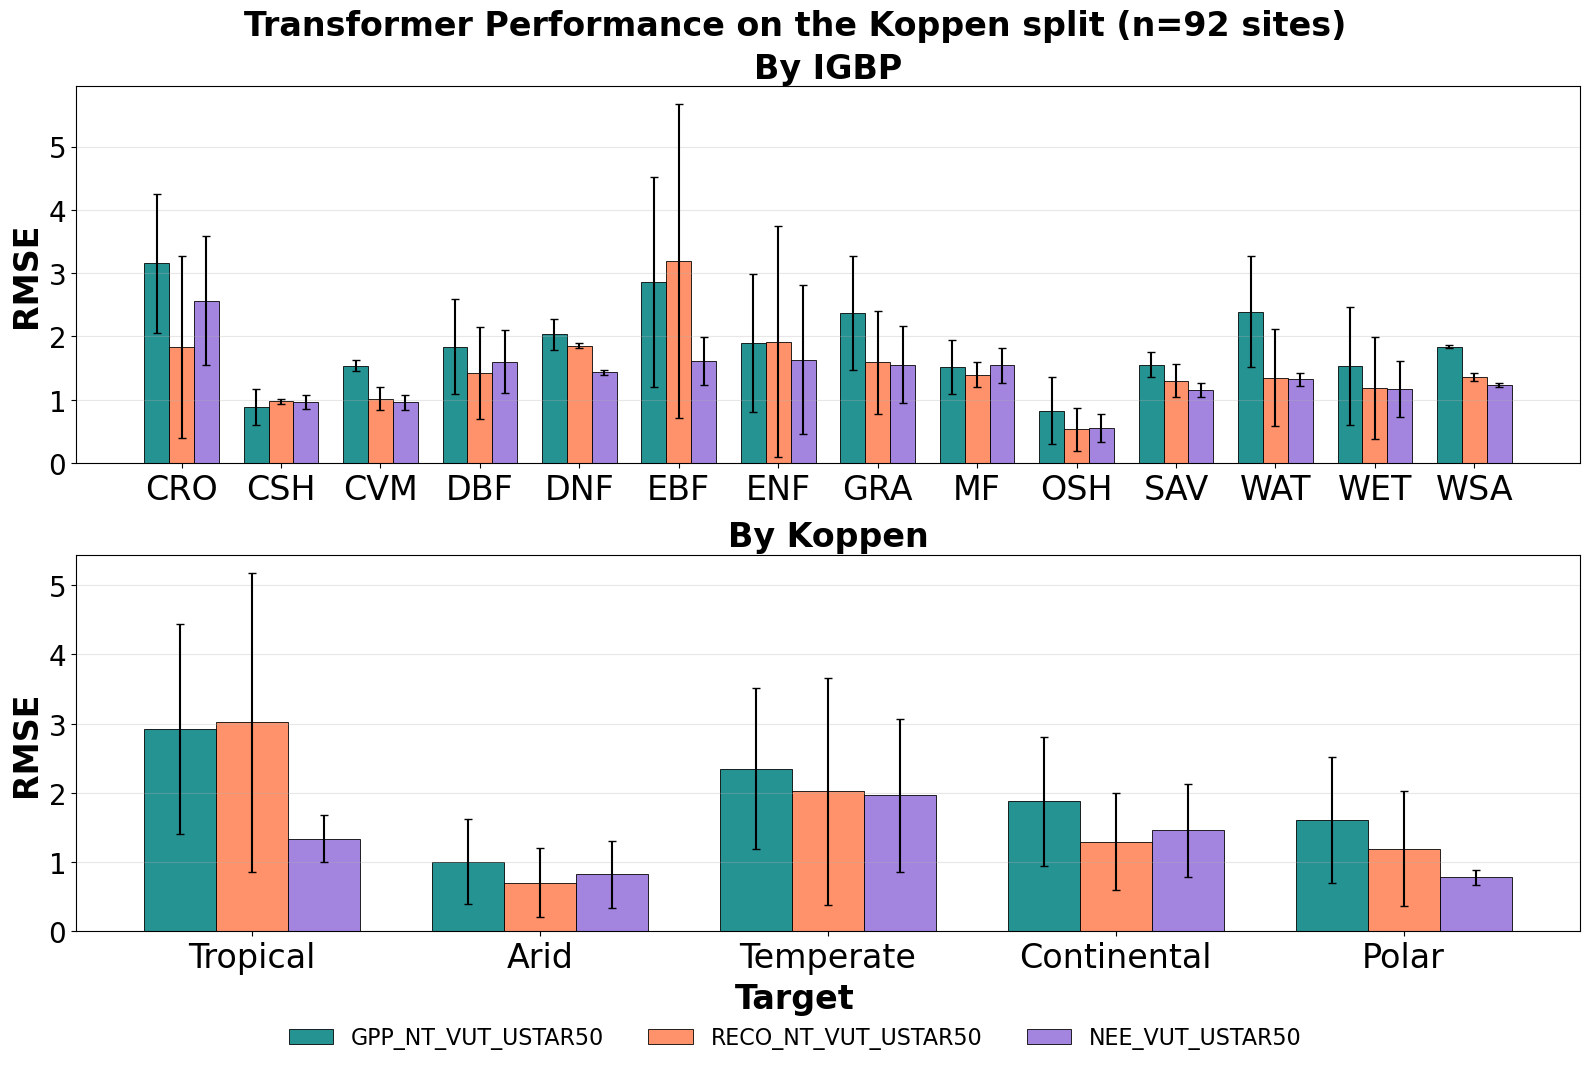

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

targets_map = {
    'GPP_NT_VUT_USTAR50': 'GPP_NT_VUT_USTAR50',
    'RECO_NT_VUT_USTAR50': 'RECO_NT_VUT_USTAR50',
    'NEE_VUT_USTAR50': 'NEE_VUT_USTAR50'
}

koppen_map = {
    'A': 'Tropical',
    'B': 'Arid',
    'C': 'Temperate',
    'D': 'Continental',
    'E': 'Polar'
}

colors = ['teal', 'coral', 'mediumpurple']

for ax_idx, category_col in enumerate(['IGBP', 'Koppen']):
    ax = axes[ax_idx]
    categories = sorted(df[category_col].unique())
    
    # Map Koppen if needed
    if category_col == 'Koppen':
        categories_display = [koppen_map.get(cat[0], cat) for cat in categories]
    else:
        categories_display = categories
    
    n_cats = len(categories)
    x = np.arange(n_cats)
    width = 0.25
    
    for k, (target_full, target_short) in enumerate(targets_map.items()):
        means = []
        stds = []
        for cat in categories:
            subset = df[(df['target'] == target_full) & 
                       (df['model'] == 'transformer') & 
                       (df[category_col] == cat)]
            means.append(subset['RMSE'].mean())
            stds.append(subset['RMSE'].std())
        
        ax.bar(x + k*width, means, width, label=target_short, yerr=stds,
               capsize=3, alpha=0.85, color=colors[k], 
               edgecolor='black', linewidth=0.7)
    
#     ax.set_xlabel(category_col, fontsize=12, fontweight='bold')
    ax.set_ylabel('RMSE', fontsize=24, fontweight='bold')
    ax.set_title(f'By {category_col}', 
                fontsize=24, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(categories_display, rotation=0, ha='center', fontsize=24)
    ax.grid(axis='y', alpha=0.3)

# Shared legend
from matplotlib.patches import Rectangle
handles_temp, labels = axes[0].get_legend_handles_labels()
colors_legend = [ha.patches[0].get_facecolor() for ha in handles_temp]
new_handles = [Rectangle((0,0), 1, 1, facecolor=c, edgecolor='black', 
                         linewidth=0.7, alpha=0.85) for c in colors_legend]

fig.legend(new_handles, labels, loc='lower center', ncol=3, frameon=False,
           fontsize=16, bbox_to_anchor=(0.5, -0.08), title='Target', 
           title_fontproperties={'weight': 'bold', 'size': 24})

plt.suptitle(f'Transformer Performance on the Koppen split (n={df["site"].nunique()} sites)', 
            fontsize=24, fontweight='bold')
plt.tight_layout()
plt.savefig('./figs/transformer_rmse_comparison.png', bbox_inches='tight')
plt.show()